<a href="https://colab.research.google.com/github/JakeOh/202511_BD53/blob/main/lab_ml/ml17_ann_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST 데이터셋 이미지 분류

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

In [2]:
tf.__version__

'2.19.0'

In [3]:
keras.__version__

'3.13.2'

In [4]:
print(tf.config.list_physical_devices())  # CPU/GPU/TPU 사용 여부 확인

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [5]:
print(keras.config.backend())  # keras 라이브러리에서 텐서 연산을 할 때 필요한 라이브러리.

tensorflow


Keras 라이브러리는 텐서 연산을 직접 수행하지 않음. 대신에 텐서 연산을 수행하는 다른 딥러닝 라이브러리를 백엔드(backend)로 활용함.

*   Keras에서 사용하는 백엔드 종류
    *   TensorFlow - 구글에서 만든 텐서 연산 라이브러리.
    *   PyTorch - 메타에서 만든 딥러닝 라이브러리 -> 리눅스 재단으로 이전, 오픈소스로 공개됨.
*   Keras
    *   여러가지 백엔드를 사용해서 신경망을 쉽게 만들고 훈련할 수 있도록 만든 고급 라이브러리.
    *   2.3.1 버전 이후부터는 TensorFlow만 단일 백엔드로 사용하도록 기능 변경.
    *   3.0 버전부터 다시 멀티 백엔드 정책으로 바뀜.

# Fashion MNIST 데이터 셋

10개 클래스(예: 바지, 셔츠, 구두, ...)의 패션 아이템들의 28x28 크기의 흑백 이미지. 60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train.shape  #> (n_samples, width, height)

(60000, 28, 28)

In [8]:
y_train.shape  #> (n_samples)

(60000,)

In [9]:
x_test.shape

(10000, 28, 28)

In [10]:
y_test.shape

(10000,)

In [11]:
# 훈련 레이블의 중복되지 않는 값들 개수
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [12]:
# 테스트 레이블의 중복되지 않는 값들
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

훈련 셋과 테스트 셋 모두 각 클래스의 샘플들이 같은 개수로 수집되어 있음.

In [13]:
x_train[0]  #> 0(black) ~ 255(white) scale의 28x28 크기의 흑백 이미지

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

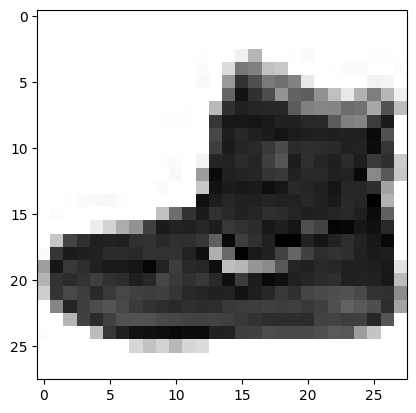

In [14]:
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()

In [15]:
def plot_fashion_mnist(arr, ncols=10):
    # arr: (n_samples, width, height) shape의 3차원 배열
    # ncols: subplot axis의 컬럼 개수.
    n = len(arr)  # 출력할 이미지 개수
    nrows = int(np.ceil(n / ncols))  # subplot axis의 행 개수
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j  # 배열 arr에서 선택할 이미지의 인덱스
            if nrows == 1 or ncols == 1:  # axes는 1차원 배열
                if idx < n:
                    axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
                axes[idx].axis('off')
            else:  # axes는 2차원 배열
                if idx < n:
                    axes[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                axes[i, j].axis('off')
    plt.show()

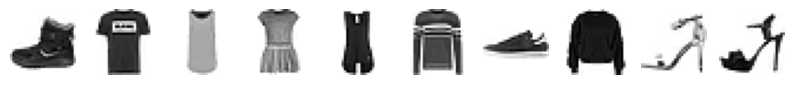

In [16]:
plot_fashion_mnist(x_train[:10])

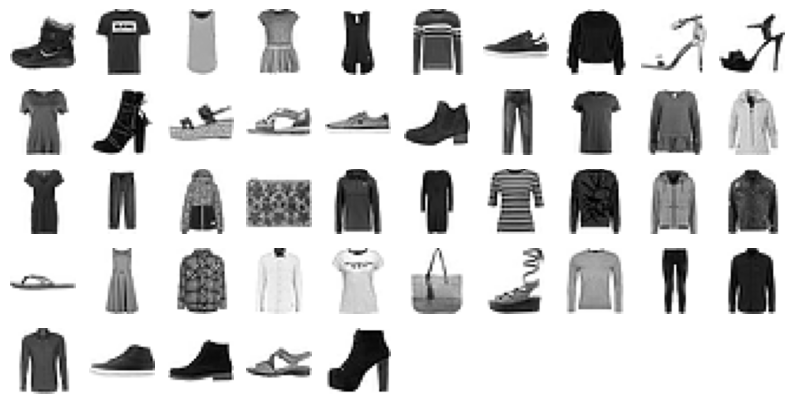

In [17]:
plot_fashion_mnist(x_train[:45])

# 훈련 셋 스케일링, 훈련/검증 분리

In [18]:
# 훈련 셋의 스케일을 0 ~ 1 사이의 값으로 변경 -> SGDClassifier의 성능 향상을 위해서
x_train_scaled = x_train / 255

In [19]:
# 훈련 셋과 훈련 레이블을 훈련/검증으로 분리
train_input, val_input, train_target, val_target = train_test_split(x_train_scaled, y_train,
                                                                    test_size=0.2,
                                                                    random_state=42,
                                                                    stratify=y_train)

In [20]:
train_input.shape

(48000, 28, 28)

In [21]:
train_target.shape

(48000,)

# SGD Classifier

In [22]:
sgd = SGDClassifier(loss='log_loss', random_state=42, n_jobs=-1)  # 모델 생성

In [23]:
# 모델 훈련 - (주의) 훈련 셋은 (n_samples, n_features) shape의 2차원 배열이어야 함!
sgd.fit(X=train_input.reshape((48_000, -1)), y=train_target)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [24]:
sgd.coef_.shape

(10, 784)

In [25]:
sgd.intercept_.shape

(10,)

In [26]:
# 각 클래스가 될 확률
predict_probs = sgd.predict_proba(X=train_input.reshape((48_000, -1)))

In [27]:
predict_probs[:2]

array([[1.20888251e-02, 1.05549631e-05, 2.30094285e-01, 3.41231387e-03,
        4.86284532e-02, 3.96063160e-10, 6.91742929e-01, 1.54454383e-17,
        1.40226378e-02, 1.05805064e-16],
       [7.53889861e-01, 1.20438290e-04, 4.89841116e-05, 2.88644150e-04,
        7.52168267e-02, 4.15812599e-17, 1.69806662e-01, 2.22627871e-15,
        6.28584469e-04, 3.41774283e-15]])

In [28]:
predicts = sgd.predict(X=train_input.reshape((48_000, -1)))

In [29]:
predicts[:2]

array([6, 0], dtype=uint8)

In [30]:
accuracy_score(y_true=train_target, y_pred=predicts)  # 훈련 셋 정확도

0.8518125

In [31]:
# 검증 셋 평가
val_input_2d = val_input.reshape((12_000, -1))  # 3d 배열 -> 2d 배열
val_predicts = sgd.predict(X=val_input_2d)  # 검증 셋 예측값
accuracy_score(y_true=val_target, y_pred=val_predicts)  # 검증 셋 정확도

0.8468333333333333

# 입력층과 출력층만 갖는 신경망

In [32]:
train_input_2d = train_input.reshape((48_000, -1))
train_input_2d.shape

(48000, 784)

In [33]:
# 입력층(input layer)
inputs = keras.Input(shape=(784,))

In [34]:
# 출력층(output layer)
dense = keras.layers.Dense(units=10, activation='softmax')

In [35]:
# 완전연결 신경망
model = keras.Sequential(layers=[inputs, dense])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 신경망 모델 컴파일
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [38]:
# 신경망 모델 훈련
model.fit(x=train_input_2d, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0334 - sparse_categorical_accuracy: 0.6744
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7106 - sparse_categorical_accuracy: 0.7719
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6385 - sparse_categorical_accuracy: 0.7942
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5992 - sparse_categorical_accuracy: 0.8065
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5730 - sparse_categorical_accuracy: 0.8137
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5545 - sparse_categorical_accuracy: 0.8188
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5400 - sparse_categorical_accuracy: 0.8228
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5286 - sparse_categorical_accuracy: 0.8269
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5188 - sparse_categorical_accuracy: 0.8300
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - 

In [39]:
# 훈련된 신경망 모델이 찾은 모델 파라미터들(가중치, weights)
model.weights

[<Variable path=sequential/dense/kernel, shape=(784, 10), dtype=float32, value=[[-0.05077262  0.04368586 -0.02748059 ...  0.02595025  0.03728536
    0.01219677]
  [ 0.08047859 -0.03918079 -0.07186085 ...  0.01563701  0.00350974
   -0.00724229]
  [ 0.0568295  -0.08454666 -0.01419383 ... -0.03599423 -0.0055062
    0.02950988]
  ...
  [ 0.01329666  0.04979062 -0.04030746 ... -0.07772733  0.03189939
   -0.0780042 ]
  [-0.09153212 -0.04417865  0.00878954 ... -0.07338593 -0.09289474
    0.01258244]
  [-0.07544246 -0.02018801 -0.04318523 ...  0.03260998  0.0733121
   -0.05455281]]>,
 <Variable path=sequential/dense/bias, shape=(10,), dtype=float32, value=[ 0.10701982 -0.07534105 -0.1002832   0.00845958 -0.46363628  1.1461732
   0.2300204  -0.09405896 -0.25797918 -0.5003742 ]>]

In [40]:
predicts = model.predict(x=train_input_2d)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [41]:
predicts.shape  #> (48_000, 10) = (n_samples, n_classes)

(48000, 10)

In [42]:
predicts[:2]

array([[7.5806705e-03, 4.5585507e-04, 2.9264188e-01, 2.6350740e-02,
        4.7163907e-02, 7.0365983e-05, 6.1590552e-01, 1.3300715e-06,
        9.8144729e-03, 1.5216550e-05],
       [5.6994808e-01, 3.4638314e-04, 1.9729233e-03, 1.6027203e-02,
        1.0689262e-02, 3.1490382e-07, 4.0056363e-01, 3.2458155e-07,
        4.4678710e-04, 5.1223897e-06]], dtype=float32)

In [43]:
# 훈련 셋의 예측 레이블 계산 - 10개의 확률들 중 최댓값의 인덱스.
train_pred_labels = predicts.argmax(axis=1)

In [44]:
train_pred_labels[:2]

array([6, 0])

In [45]:
accuracy_score(y_true=train_target, y_pred=train_pred_labels)  # 훈련 셋 정확도

0.8314791666666667

In [46]:
model.evaluate(x=train_input_2d, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5086 - sparse_categorical_accuracy: 0.8315


[0.5086469650268555, 0.8314791917800903]

In [47]:
# 검증 셋 정확도
model.evaluate(x=val_input_2d, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4989 - sparse_categorical_accuracy: 0.8330


[0.49891695380210876, 0.8330000042915344]

# 활성화 함수(Activation Function)

*   활성화 함수: 신경망의 각 층(layer)에서 출력을 내보내는 함수.
*   은닉층(hidden layer)에서 활성화 함수로 선형 함수를 사용하면 여러 개의 층을 연결하는 효과가 없음.
    *    단일 층을 사용하는 것과 같음.
*   은닉층에서는 비선형 함수를 활성화 함수로 사용.

## Sigmoid 함수

$
\text{sigmoid}(x) = \dfrac{1}{1 + \exp(-x)}
$

In [48]:
xvals = np.arange(-5, 5, 0.0001)

In [49]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

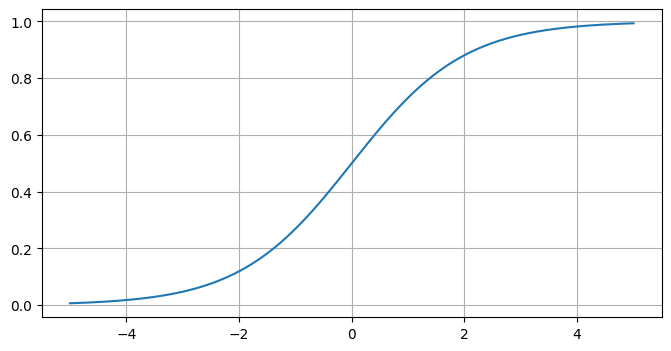

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(xvals, sigmoid(xvals))
plt.grid()
plt.show()

In [51]:
def plot_activation_fn(fn):
    xvals = np.arange(-5, 5, 0.0001)
    yvals = fn(xvals)
    plt.figure(figsize=(8, 4))
    plt.plot(xvals, yvals)
    plt.grid()
    plt.show()

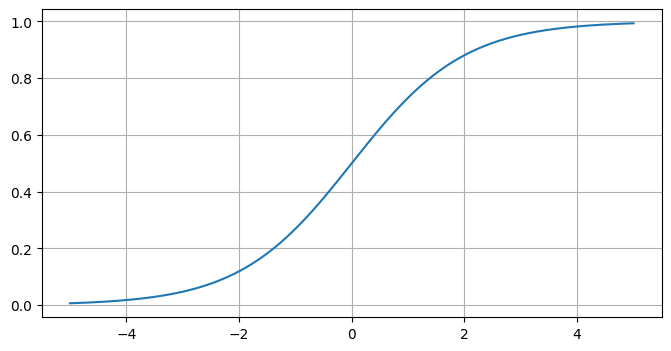

In [52]:
plot_activation_fn(sigmoid)

## Hyperbolic Tangent

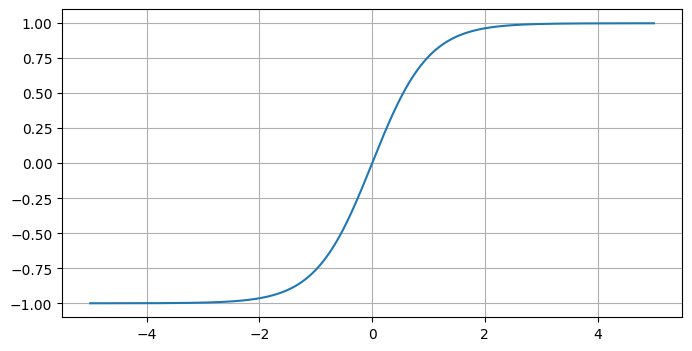

In [53]:
plot_activation_fn(np.tanh)

## ReLU(Rectified Linear Unit)

*   입력값이 양수이면 입력값 그대로 출력을 내보냄.
*   입력값이 음수이면 출력값을 0으로 만듦.
*   이미지를 처리할 때 좋은 성능을 낸다고 알려져 있음.

$
\text{ReLU}(x) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        0 & \text{for } x \lt 0
    \end{cases}
$

In [54]:
def relu(x):
    return np.maximum(x, 0)

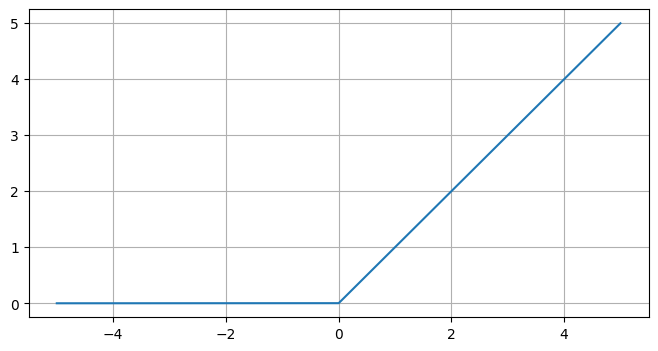

In [55]:
plot_activation_fn(relu)

## Leaky ReLU

$
\text{LeakyReLU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha x & \text{for } x \lt 0, 0 \lt \alpha \lt 1
    \end{cases}
$

In [56]:
def leaky_relu(x, alpha=0.1):
    # 0 <= alpha < 1
    return np.maximum(x, alpha * x)

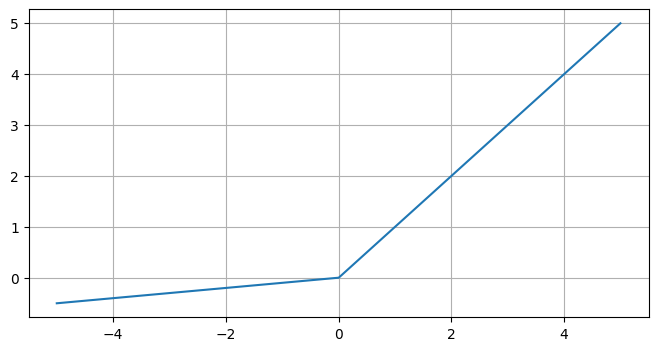

In [57]:
plot_activation_fn(leaky_relu)

## ELU(Exponential Linear Unit)

$
\text{ELU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha (\exp(x) - 1) & \text{for } x \lt 0
    \end{cases}
$

In [58]:
def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

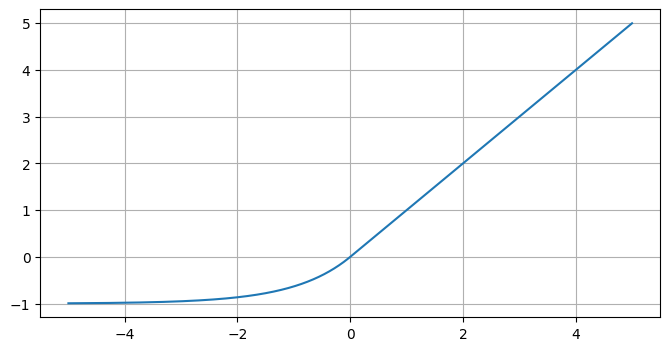

In [59]:
plot_activation_fn(elu)

은닉층에서 활성화 함수 선택: ELU > LeakyReLU > ReLU > tanh > sigmoid

# ReLU를 활성화 함수로 사용하는 은닉층

In [60]:
model = keras.Sequential()  # 완전연결 신경망

In [61]:
model.add(keras.Input(shape=(28, 28)))  # 입력층

In [62]:
# Flatten 층: (28, 28) 모양의 배열을 (784, ) 모양의 1차원 배열로 변환
model.add(keras.layers.Flatten())

In [63]:
# 은닉층: 100개의 unit들을 갖는, ReLU 활성화 함수를 사용하는 은닉층을 추가
model.add(keras.layers.Dense(units=100, activation='relu'))

In [64]:
# 출력층: 10개 클래스로 분류하는 다중 클래스 분류 문제.
model.add(keras.layers.Dense(units=10, activation='softmax'))

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [67]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9184 - sparse_categorical_accuracy: 0.7130
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6053 - sparse_categorical_accuracy: 0.8009
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5424 - sparse_categorical_accuracy: 0.8186
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5098 - sparse_categorical_accuracy: 0.8273
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4891 - sparse_categorical_accuracy: 0.8323
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4735 - sparse_categorical_accuracy: 0.8400
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4616 - sparse_categorical_accuracy: 0.8425
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4516 - sparse_categorical_accuracy: 0.8449
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4432 - sparse_categorical_accuracy: 0.8473
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - 

In [68]:
model.evaluate(x=train_input, y=train_target)  # 훈련 셋 평가

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4254 - sparse_categorical_accuracy: 0.8545


[0.4253958463668823, 0.8544999957084656]

In [69]:
model.evaluate(x=val_input, y=val_target)  # 검증 셋 평가

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4227 - sparse_categorical_accuracy: 0.8557


[0.4226982295513153, 0.8556666374206543]

# ELU 활성화함수 은닉층

Input --> Flatten --> Dense(100 units, elu) --> Dense

In [70]:
model = keras.Sequential()  # 완전연결 신경망
model.add(keras.Input(shape=(28, 28)))  # 입력층(input layer)
model.add(keras.layers.Flatten())  # flatten layer
model.add(keras.layers.Dense(units=100, activation='elu'))  # 은닉층(hidden layer)
model.add(keras.layers.Dense(units=10, activation='softmax'))  # 출력층(output layer)

In [71]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [73]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9020 - sparse_categorical_accuracy: 0.7107
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6044 - sparse_categorical_accuracy: 0.7999
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5418 - sparse_categorical_accuracy: 0.8178
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5097 - sparse_categorical_accuracy: 0.8265
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4893 - sparse_categorical_accuracy: 0.8329
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4751 - sparse_categorical_accuracy: 0.8371
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4628 - sparse_categorical_accuracy: 0.8409
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4538 - sparse_categorical_accuracy: 0.8439
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4459 - sparse_categorical_accuracy: 0.8456
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - 

In [74]:
model.evaluate(x=train_input, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4305 - sparse_categorical_accuracy: 0.8512


[0.4305229187011719, 0.851229190826416]

In [75]:
model.evaluate(x=val_input, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4238 - sparse_categorical_accuracy: 0.8537


[0.4237872362136841, 0.8537499904632568]

# Optimizer

**Optimizer(최적화 함수)**

*   손실함수를 최소화시키는 과정에서 모델 파라미터(가중치)들을 최적화하는 알고리즘.
*   경사하강법(Gradient Descent): 손실함수의 기울기가 줄어드는 방향으로 모델 파라미터들을 최적화시키는 알고리즘.

>> $w_{next} = w_{init} - \text{learning_rate} \cdot \text{gradient}$

*   아주 큰(깊은) 신경망인 경우는 모델 훈련에서 찾아야 하는 가중치들의 개수가 매우 많음.
*   모델 파라미터(가중치)들의 개수가 많을 수록 훈련 속도가 심각하게 느려질 수 있음.
*   훈련 속도를 빠르게 하는 방법:
    *   좋은 초기화 전략 사용하기
    *   좋은 활성화 함수 사용하기
    *   배치 정규화 사용하기
    *   사전 훈련된 네트워크(신경망)의 일부를 재사용
    *   일반적인 경사 하강법 대신 더 빠른 옵티마이저를 사용하기
*   SGD(Stochastic Gradient Descent, 확률적 경사 하강법)의 파라미터 변경 - SGD 변종 옵티마이저
    *   learning_rate(학습률) 파라미터를 변경
    *   momentum(모멘텀) 파라미터 값을 0보다 큰 값으로 변경 - **모멘텀 최적화(momentum optimization)**
    *   nesterov(네스테로프) 파라미터를 True로 변경 - **네스테로프 가속 경사(NAG, Nesterov Accelerated Gradient)**
*   적응형 학습률(adaptive learning rate)을 사용한 옵티마이저
    *   학습할 때마다 학습률을 변화시킴.
    *   RMSprop(Root Mean Squared Propagation): compile 메서드 optimzer 파라미터의 기본값.
    *   Adam(Adaptive Mementum Estimation): 모멘텀 최적화 + RMSprop
    *   Nadam: Adam + Nesterov
    *   AdaGrad: 파라미터마다 학습률을 개별적으로 적응시키는 옵티마이저. 자주 업데이트되는 파라미터는 학습률을 줄이고, 드물게 학습되는 파라미터는 학습률을 높여 자주 등장하지 않는 피쳐의 가중치를 크게 업데이트하는 효과.

## RMSProp 옵티마이저

In [76]:
def create_model(layers=None):
    # layers: keras.layers 객체(예: Dense)들의 배열/리스트. 깊은 신경망(deep neural network)을 만들기 위한 레이어.
    model = keras.Sequential()  # 완전연결 신경망
    model.add(keras.Input(shape=(28, 28)))  # 입력층
    model.add(keras.layers.Flatten())  # flatten layer: (28, 28) -> (784,)
    model.add(keras.layers.Dense(units=100, activation='elu'))  # 첫번째 은닉층
    if layers:  # 아규먼트로 전달된 은닉층들이 있으면
        for l in layers:
            model.add(l)
    model.add(keras.layers.Dense(units=10, activation='softmax'))

    return model

In [77]:
model1 = create_model()

In [78]:
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

RMSprop 파라미터:
*   `learning_rate`: 학습률.
*   `rho`: 감쇠율(decay rate). 과거 기울기 정보를 얼마나 유지할 지를 설정.
*   `momentum`: 모멘텀(관성)을 주는 정도.

In [79]:
model1.compile(optimizer=keras.optimizers.RMSprop(),  # optimizer='rmsprop'
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [80]:
model1.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5657 - sparse_categorical_accuracy: 0.8003
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4165 - sparse_categorical_accuracy: 0.8508
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3775 - sparse_categorical_accuracy: 0.8623
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3505 - sparse_categorical_accuracy: 0.8712
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3322 - sparse_categorical_accuracy: 0.8774
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3163 - sparse_categorical_accuracy: 0.8840
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3036 - sparse_categorical_accuracy: 0.8877
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2931 - sparse_categorical_accuracy: 0.8920
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2826 - sparse_categorical_accuracy: 0.8945
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - 

In [81]:
model1.evaluate(x=train_input, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2429 - sparse_categorical_accuracy: 0.9103


[0.2428859919309616, 0.9102916717529297]

In [82]:
model1.evaluate(x=val_input, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2985 - sparse_categorical_accuracy: 0.8928


[0.29853516817092896, 0.8928333520889282]

## Adam 옵티마이저

In [83]:
model2 = create_model()
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Adam 파라미터:
*   `learning_rate`: 학습률
*   `beta_1`: 모멘텀
*   `beta_2`: RMSprop의 `rho`와 비슷

In [84]:
model2.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [86]:
model2.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3867 - sparse_categorical_accuracy: 0.8596
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3613 - sparse_categorical_accuracy: 0.8694
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3409 - sparse_categorical_accuracy: 0.8755
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3229 - sparse_categorical_accuracy: 0.8818
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3073 - sparse_categorical_accuracy: 0.8872
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2935 - sparse_categorical_accuracy: 0.8917
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2829 - sparse_categorical_accuracy: 0.8956
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2718 - sparse_categorical_accuracy: 0.8989
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2611 - sparse_categorical_accuracy: 0.9031
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - 

In [87]:
model2.evaluate(x=train_input, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2358 - sparse_categorical_accuracy: 0.9118


[0.23579488694667816, 0.9118333458900452]

In [88]:
model2.evaluate(x=val_input, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3051 - sparse_categorical_accuracy: 0.8917


[0.3051445782184601, 0.8916666507720947]

# 모델의 저장과 복원

`History` 객체: 신경망 모델을 훈련(fit)시키는 과정(각각의 epoch)의 기록을 담고 있는 객체. `fit` 메서드의 리턴 타입.

RMSprop 옵티마이저, epoch 20회, 훈련/검증 정확도, 손실 그래프

In [98]:
model = create_model()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [100]:
result = model.fit(x=train_input, y=train_target, batch_size=64, epochs=20,
                   validation_data=[val_input, val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.5604 - sparse_categorical_accuracy: 0.8033 - val_loss: 0.4233 - val_sparse_categorical_accuracy: 0.8469
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4173 - sparse_categorical_accuracy: 0.8492 - val_loss: 0.3724 - val_sparse_categorical_accuracy: 0.8662
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3758 - sparse_categorical_accuracy: 0.8646 - val_loss: 0.3561 - val_sparse_categorical_accuracy: 0.8720
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3490 - sparse_categorical_accuracy: 0.8725 - val_loss: 0.3400 - val_sparse_categorical_accuracy: 0.8810
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3314 - sparse_categorical_accuracy: 0.8774 - val_loss: 0.3436 - val_sparse_categorical_accuracy: 0.8756
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3156 - sparse_categorical_accuracy: 0.8845 - val_loss: 0.3220 - val_sparse_categorical_accuracy: 0.8829
Epoc

In [101]:
print(type(result))

<class 'keras.src.callbacks.history.History'>


In [102]:
history = result.history
history  #> dict 타입 객체 - 훈련 손실, 훈련 정확도, 검증 손실, 검증 정확도

{'loss': [0.5603681802749634,
  0.41730862855911255,
  0.375777006149292,
  0.3489859700202942,
  0.33143267035484314,
  0.31555578112602234,
  0.3017483949661255,
  0.2924642264842987,
  0.28317248821258545,
  0.27487748861312866,
  0.26678594946861267,
  0.25984296202659607,
  0.2535110414028168,
  0.24754416942596436,
  0.24085849523544312,
  0.23626168072223663,
  0.2307136505842209,
  0.22620537877082825,
  0.22178871929645538,
  0.2173296958208084],
 'sparse_categorical_accuracy': [0.8032708168029785,
  0.8491666913032532,
  0.8646041750907898,
  0.8725416660308838,
  0.8774374723434448,
  0.8845416903495789,
  0.8898541927337646,
  0.8926041722297668,
  0.8961250185966492,
  0.898687481880188,
  0.9010624885559082,
  0.9027916789054871,
  0.9067708253860474,
  0.9090833067893982,
  0.9112916588783264,
  0.9128958582878113,
  0.9161458611488342,
  0.9162708520889282,
  0.918874979019165,
  0.9218124747276306],
 'val_loss': [0.4232501983642578,
  0.3724342882633209,
  0.3560982942

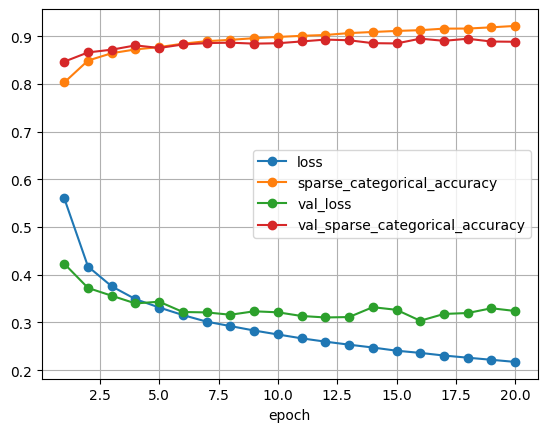

In [104]:
epochs = np.arange(1, 21)
for k, v in history.items():
    plt.plot(epochs, v, 'o-', label=k)
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.show()

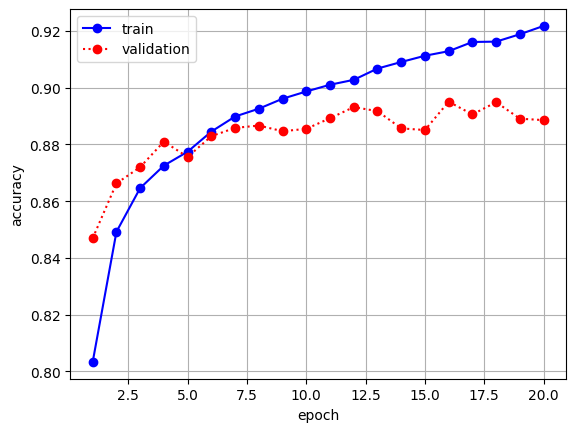

In [105]:
# 에포크에 따른 정확도 변화
plt.plot(epochs, history['sparse_categorical_accuracy'], 'bo-', label='train')
plt.plot(epochs, history['val_sparse_categorical_accuracy'], 'ro:', label='validation')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid()
plt.show()

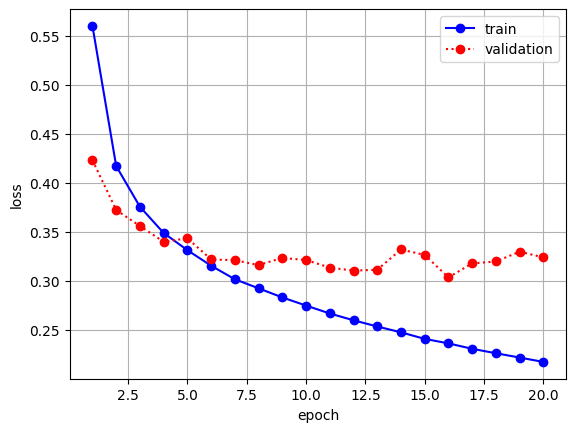

In [106]:
# epoch에 따른 손실 변화
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid()
plt.show()

Adam 옵티마이저를 사용, epoch 20회, 훈련/검증 셋의 손실 그래프

In [107]:
model = create_model()
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result = model.fit(x=train_input, y=train_target, batch_size=64, epochs=20,
                   validation_data=[val_input, val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5468 - sparse_categorical_accuracy: 0.8104 - val_loss: 0.4200 - val_sparse_categorical_accuracy: 0.8518
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4097 - sparse_categorical_accuracy: 0.8540 - val_loss: 0.3886 - val_sparse_categorical_accuracy: 0.8623
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3751 - sparse_categorical_accuracy: 0.8654 - val_loss: 0.3655 - val_sparse_categorical_accuracy: 0.8688
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3470 - sparse_categorical_accuracy: 0.8731 - val_loss: 0.3456 - val_sparse_categorical_accuracy: 0.8762
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3297 - sparse_categorical_accuracy: 0.8792 - val_loss: 0.3421 - val_sparse_categorical_accuracy: 0.8760
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3109 - sparse_categorical_accuracy: 0.8848 - val_loss: 0.3561 - val_sparse_categorical_accuracy: 0.8722
Epoc

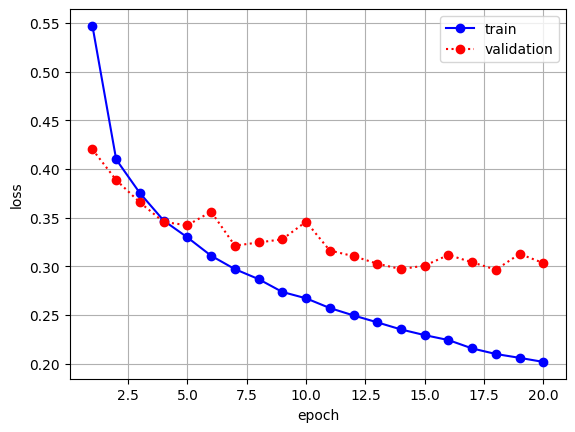

In [108]:
history = result.history
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()